"New York City Airbnb Open Data"

# Inserting, cleaning, and exploring dataset

In [ ]:
#importing the data into colab and checking it worked using .head()
import pandas as pd
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ProjectBCIS321/AB_NYC_2019.csv.zip')
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [ ]:
#checking for missing values and the info of the df
df.info()
# the dataset should have 48895 total values. name is missing 16 values
# host is missing 21 values
# last_review and reviews_per_month is missing 10,052

## checking for duplicated values
total_duplicated = df.duplicated().sum()
print('The number of duplicated values is', total_duplicated)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     

In [ ]:
#altering the missing values in the dataset
df['reviews_per_month']=df[['reviews_per_month']].fillna(value=0)
df.drop(columns='last_review', inplace=True)

df['name']=df[['name']].fillna(value='Unknown')
df['host_name']=df[['host_name']].fillna(value='Unknown')

In [ ]:
# checking 'last_review table' is removed & values for 'reviews_per_month' are completed at 48895 rows.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48895 non-null  object 
 2   host_id                         48895 non-null  int64  
 3   host_name                       48895 non-null  object 
 4   neighbourhood_group             48895 non-null  object 
 5   neighbourhood                   48895 non-null  object 
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  object 
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  reviews_per_month               

In [ ]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,4.889500e+04,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,1.901714e+07,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327
std,1.098311e+07,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289
min,2.539000e+03,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000
25%,9.471945e+06,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000
50%,1.967728e+07,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000
75%,2.915218e+07,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000
max,3.648724e+07,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000


In [ ]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0


#Creating Visualizations

# Countplot: Listings Per Room_Type

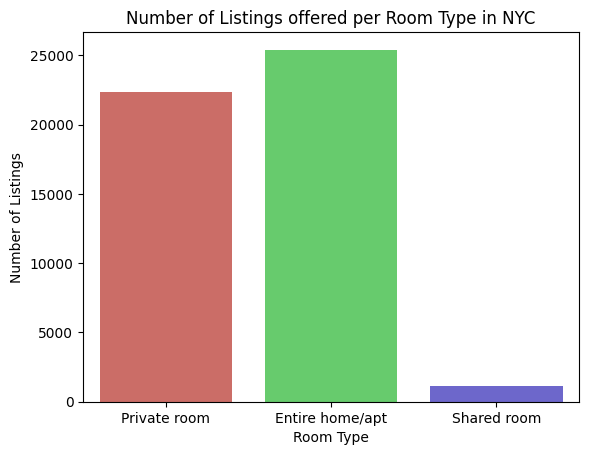

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ProjectBCIS321/AB_NYC_2019.csv.zip')
sns.countplot(x='room_type', data=df, hue= 'room_type', palette='hls')
plt.title('Number of Listings offered per Room Type in NYC')
plt.xlabel('Room Type')
plt.ylabel('Number of Listings')
plt.savefig('Number_of_listings_Per_Room_Type.png', bbox_inches='tight')
plt.show()

## Interpretation ---
# This count plot shows the number of listings available by each room type.
# Entire homes/apt have the highest number of Airbnb listings at about 25,000 while there are about 1,000 "shared rooms" listings in NYC.

# Histogram: Price Distribution

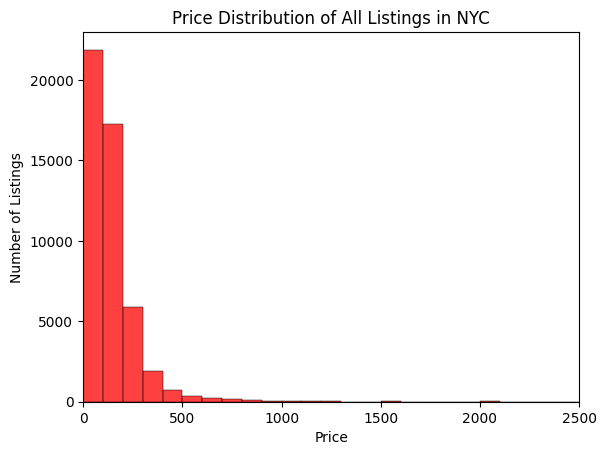

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ProjectBCIS321/AB_NYC_2019.csv.zip')
sns.histplot(x='price', data=df, bins=100, kde=False, color='red')
plt.xlim(0,2500)
plt.title('Price Distribution of All Listings in NYC')
plt.xlabel('Price')
plt.ylabel('Number of Listings')
plt.savefig('price_distribution.png', bbox_inches='tight')
plt.show()
## Interpretation ---
# This graph shows the price distribution of all listings in NYC despite the location.
# It demonstrates a right skew where most of the listings are below $100-$200 a night.
# There is a sharp decline after $200 in listings as prices increase but the graph does have a
# long tail that indicates that there are a few high-end airbnb listings available.


# Catplot: Price range by Neighborhood Group

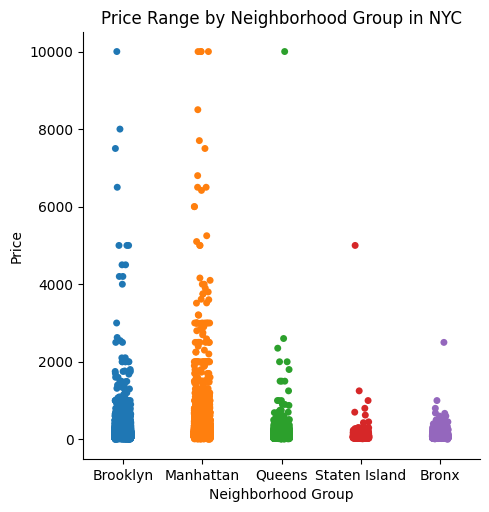

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ProjectBCIS321/AB_NYC_2019.csv.zip')

sns.catplot(x='neighbourhood_group', y='price', data=df, hue='neighbourhood_group')
plt.title('Price Range by Neighborhood Group in NYC')
plt.xlabel('Neighborhood Group')
plt.ylabel('Price')
plt.savefig('price_range_by_neighborhood_group_catplot.png', bbox_inches='tight')
plt.show()
## Interpretation ---
# This cat plot shows the price ranges of airbnb listings in different neighborhood groups in NYC in 2019.
# Based on this graph, we can see that Bronx and Staten Islan have a very small range of prices while
# Manhattan has the most versatile range. For Manhattan, this chart assumes that it is the most expensive neighborhood group.
# However, there is a wide range of accommodations: from very affordable to very expensive listings.
# Queens offers less variability than Manhattan and Brooklyn but more expensive prices than Staten Island and Bronx.
# Queens provides a moderate pricing but there is a more expensive listing that could reflect a luxurious listing or an excessively high-priced listing.

#Boxplot: Availibility out of 365 Days per Room Type

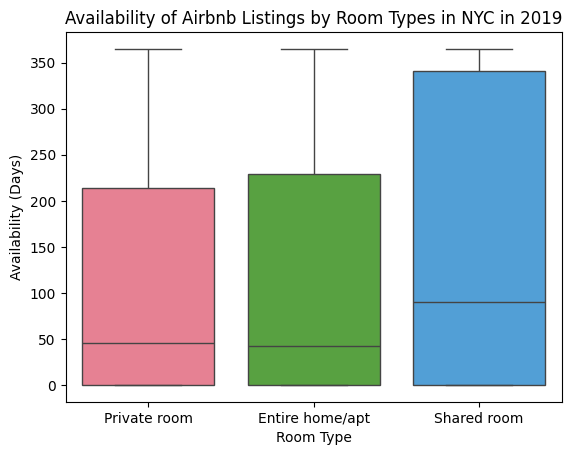

In [ ]:
## creating a boxplot for the type of rooms avaiable and how many days they were available for during 2019
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/ProjectBCIS321/AB_NYC_2019.csv.zip')

sns.boxplot(x='room_type', y='availability_365', data=df, hue='room_type', palette='husl')
plt.title('Availability of Airbnb Listings by Room Types in NYC in 2019')
plt.xlabel('Room Type')
plt.ylabel('Availability (Days)')
plt.savefig('availibility365_by_room_type_boxplot.png')
plt.show()

## Interpretation ----
# This boxplot shows the availability (in days per year) over different room types for Airbnb listings in NYC.
# Private rooms and enntire homes/apt have a lower median in comparison to a shared room, ind. In addition,
# shared rooms have a significantly wider range of values where the third quartile is found at around 340 days of the year.
# This would be interpreted as more than 75% of the shared rooms listings are available for most part of the year.
# More availibility could be interpreted as being the listings people don't gravitate towards, or it could mean there's significantly
# more shared rooms listings and that's why they're available more often than not.

#Creating an interactive map to view the population of Airbnb per neighbourhood group in NYC

In [ ]:
#creating a map of NYC
## Step 1: loading the libraries
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import folium
from folium import plugins

map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)

map

In [ ]:
#Adding layers to our map so we can see it in white and grey, makes it less clustered but still want to give the viewer the opportunity to view the map as is
map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)
folium.TileLayer('cartodbpositron').add_to(map)
folium.TileLayer('openstreetmap').add_to(map)
folium.LayerControl().add_to(map)
map

In [ ]:
#Adding markers to each data point
map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)

# Initially, too much data was input, created a sample data of the first 1000 values for a less clustered output.
sampledata = df.sample(1000)
for _, row in sampledata.iterrows():
  folium.Marker([row['latitude'], row['longitude']]).add_to(map)

map

In [ ]:
# Adding colors to my dataset
# Bringing the previously generated codes into the dataset
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import folium
from folium import plugins

map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)

folium.TileLayer('cartodbpositron').add_to(map)
folium.TileLayer('openstreetmap').add_to(map)
folium.LayerControl().add_to(map)
# Only bringing 'sampledata' rather than the code because it creates a second point on the map of the same locations
sampledata = df.sample(1000)
# Adding colors to our neighborhood groups
for i, row in sampledata.iterrows():
  color = {'Manhattan': 'orange','Brooklyn': 'red','Queens': 'green','Bronx': 'purple','Staten Island': 'darkblue'}
  folium.Marker(location=[row['latitude'], row['longitude']], icon=folium.Icon(color=color[row['neighbourhood_group']])).add_to(map)

map

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import folium
from folium import plugins

map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)

folium.TileLayer('cartodbpositron').add_to(map)
folium.TileLayer('openstreetmap').add_to(map)
folium.LayerControl().add_to(map)
# Only bringing 'sampledata' rather than the code because it creates a second point on the map of the same locations
sampledata = df.sample(1000)
# Adding colors to our neighborhood groups
for i, row in sampledata.iterrows():
  color = {'Manhattan': 'orange','Brooklyn': 'red','Queens': 'green','Bronx': 'purple','Staten Island': 'darkblue'}
  folium.CircleMarker(location=[row['latitude'], row['longitude']], radius=2, color=color[row['neighbourhood_group']], fill=True, fill_opacity=1).add_to(map)

map

In [ ]:
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import folium
from folium import plugins

map = folium.Map(location=[40.730610, -73.935242], zoom_start=11)

folium.TileLayer('cartodbpositron').add_to(map)
folium.TileLayer('openstreetmap').add_to(map)
folium.LayerControl().add_to(map)
# Only bringing 'sampledata' rather than the code because it creates a second point on the map of the same locations
sampledata = df.sample(1000)
# Adding colors to our neighborhood groups
for i, row in sampledata.iterrows():
  color = {'Manhattan': 'orange','Brooklyn': 'red','Queens': 'green','Bronx': 'purple','Staten Island': 'darkblue'}
  folium.CircleMarker(location=[row['latitude'], row['longitude']], radius=2, color=color[row['neighbourhood_group']], fill=True, fill_opacity=1).add_to(map)

#Creating a legend using HTML
# Define the legend's HTML
legend_html = '''
<div style="position: fixed;
     top: 50px; left: 50px; width: 200px; height: 150px;
     border:2px solid grey; z-index:9999; font-size:14px;
     background-color:white; opacity: 0.85;">
     &nbsp; <b>Legend</b> <br>
     &nbsp; Manhattan &nbsp; <i class="fa fa-circle" style="color:orange"></i><br>
     &nbsp; Brooklyn &nbsp; <i class="fa fa-circle" style="color:red"></i><br>
     &nbsp; Queens &nbsp; <i class="fa fa-circle" style="color:green"></i><br>
     &nbsp; Bronx &nbsp; <i class="fa fa-circle" style="color:purple"></i><br>
     &nbsp; Staten Island &nbsp; <i class="fa fa-circle" style="color:darkblue"></i><br>
</div>
'''
().html.add_child(folium.Element(legend_html))
# Add the legend to the map
map.get_root

#Adding a title
title_html = '''
             <h3 align="center" style="font-size:20px"><b>Map of Airbnb Listings in NYC by Neighborhood Group</b></h3>
             '''
map.get_root().html.add_child(folium.Element(title_html))

# Saving the map to an HTML file
map.save('map_with_legend.html')
map

## Interpretation ---
# The map shows the population of airbnbs in different neighborhood groups where we can see that Manhattan has the most listings
#  whereas Staten Island has the least. The airbnb listings of Bronx and Staten Island are far more dispersed in
# comparison to Manhattan and even Brooklyn.